# **CHOCOLATE SALES IN 2022–2023 DATASET ANALYSIS**

Importing the dependencies
Then also import the kaggle dataset (https://www.kaggle.com/datasets/arjunmehta1992/chocolate-sales-in-20222023)

In [195]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/matoxki/Documents/MyProjectsInPython/Chocolate_Sales.csv')

** OUTLINE **

1. Data Exploration
2. Data Cleaning
3. Exploratory Data Analysis and Insights Generation
4. Recommendations

**1. DATA EXPLORATION**



Preview the dataset values, Shape and Structure

In [196]:
df.shape

(200000, 11)

Chocolate Sales Dataset contains a total of 200000 Records and 11 columns 

I will preview a sample of the dataset(20 rows) 

In [197]:
df.sample(n=20, random_state=42)

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
119737,ORD-091264,Mint Dark Bar,Brazil,Retail,Rafael Oliveira,2023-01-27,16.98,2.76,110.33,308,777.62
72272,ORD-019813,70% Dark Bar,Australia,Online,Priya Sharma,2022-02-19,10.97,3.60,52.63,43,437.08
158154,ORD-044457,Salted Caramel Bar,Brazil,Wholesale,Arjun Mehta,2022-12-19,15.80,3.86,63.53,250,816.64
65426,ORD-123851,Almond Crunch Bar,Australia,Retail,Rohan Patel,2023-09-13,8.90,3.01,151.98,199,550.01
30074,ORD-073874,70% Dark Bar,Australia,Retail,Arjun Mehta,2023-04-12,17.70,3.36,58.35,110,294.28
23677,ORD-012107,70% Dark Bar,India,Wholesale,Emily Clarke,2023-08-14,10.10,17.88,94.28,32,547.04
134858,ORD-017151,White Choco Bar,Australia,Retail,Emily Clarke,2022-07-18,18.60,17.68,98.06,29,410.57
176418,ORD-054482,Truffle Gift Box,Brazil,Online,Arjun Mehta,2022-06-23,6.90,2.85,77.89,153,397.56
132467,ORD-052707,70% Dark Bar,India,Wholesale,Lukas Schmidt,2022-01-03,12.50,2.57,94.64,149,346.03
4082,ORD-096568,70% Dark Bar,Germany,Retail,Emily Clarke,2023-12-01,1.80,11.31,41.77,38,434.28


In [198]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  str    
 1   Product          200000 non-null  str    
 2   Country          200000 non-null  str    
 3   Channel          200000 non-null  str    
 4   Salesperson      200000 non-null  str    
 5   Order_Date       199563 non-null  str    
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  str    
dtypes: float64(3), int64(1), str(7)
memory usage: 16.8 MB


Observations

- Order_ID contains no null values. All 200,000 records are present
- Order_Date contains nulls which will affect time intelligence calculations
- Price_per_Box and Marketing_Spend contains nulls
- Discount_Pct contains nulls. We will have to try to reverse calculate using the other variables if present 
- Data type for Amount is str
- $ sign as prefix in some Amount values 

Next we check the dataset to have a honest null baseline

Catch uniqueness to ensure no nulls are disguised as text.

In [199]:
df.isnull().sum(), df.nunique()



(Order_ID             0
 Product              0
 Country              0
 Channel              0
 Salesperson          0
 Order_Date         437
 Discount_Pct       489
 Price_per_Box      457
 Marketing_Spend    461
 Boxes_Shipped        0
 Amount               0
 dtype: int64,
 Order_ID           200000
 Product                12
 Country                 5
 Channel                 3
 Salesperson            25
 Order_Date           2000
 Discount_Pct         2517
 Price_per_Box        1381
 Marketing_Spend     27319
 Boxes_Shipped        1521
 Amount              85605
 dtype: int64)

Uniqueness: duplicates check for Order ID to ensure we have real 200000 records and no duplicated record

In [200]:
df.duplicated().sum(), df['Order_ID'].duplicated().sum()

(np.int64(0), np.int64(0))

Consistency: does the dtype tell the truth?
This is the step that actually finds the Amount and Order_Date problems

Figures out the error in the Amount column and how large it is. MOst likely the '$' sign

Also same for the Order_Date column, figure out the format issue and how large it is

In [201]:
pd.to_numeric(df['Amount'], errors='coerce').isnull().sum()

np.int64(2750)

In [202]:
pd.to_datetime(df['Order_Date'], format='%Y-%m-%d', errors='coerce').isnull().sum()


np.int64(3323)

Plausibility: numeric ranges, all at once
every numeric column's min/max/mean/quartiles side by side
Distribution can be easily examined


In [203]:
df.describe()


,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped
count,199511.000000,199543.000000,199539.000000,200000.000000
mean,13.107457,5.911507,95.450141,139.584105
std,6.374477,4.954976,66.243760,118.665393
min,0.000000,2.040000,4.300000,-1642.000000
25%,8.300000,2.950000,52.270000,67.000000
50%,12.600000,3.280000,78.850000,113.000000
75%,17.500000,4.570000,118.710000,180.000000
max,38.300000,21.650000,798.222443,3811.000000


- As can be observed Some Boxes_Shipped contains negative value/values

In [204]:
(df['Boxes_Shipped'] < 0).sum()

np.int64(1956)

- A total of 1956 negative Boxes_Shipped values

In [205]:
df[df['Boxes_Shipped'] < 0].head()


,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
301,ORD-062584,70% Dark Bar,Australia,Retail,Arjun Mehta,2022-02-10,8.90,13.44,68.61,-25,330.28
318,ORD-069620,70% Dark Bar,Germany,Online,Lucas Walker,2023-10-25,3.70,19.18,81.72,-22,401.7
324,ORD-166180,70% Dark Bar,Australia,Retail,Priya Sharma,2023-11-20,4.70,3.25,150.86,-124,377.45
339,ORD-058464,Milk Classic Bar,Brazil,Retail,Priya Sharma,2023-01-14,15.00,3.07,31.63,-119,314.19
442,ORD-176773,70% Dark Bar,Australia,Wholesale,Priya Sharma,2023-06-26,28.26,2.47,50.57,-115,227.49


Plausibility Check 
Last, because now i already know which columns are trustworthy text, this step is just sanity checking that the number of categories makes sense (12 products, 5 countries which makes sense. 5,000 countries would not be)

In [206]:
df.select_dtypes(include=['object','string']).nunique()

Order_ID       200000
Product            12
Country             5
Channel             3
Salesperson        25
Order_Date       2000
Amount          85605
dtype: int64

**2. DATA CLEANING**

**Steps to be taken**
- Order_Date : Resolve the Order_Date multii format descripancy, remove records with missing Order_Date
- Amount column: remove $, resolve to float type
- Mathematically Reconcile Negative Boxes_Shipped: Fix the - negtive numbers, try to calculate missing values
- Reverse-engineer missing variables : calculate  Price_per_Box and Discount_Pct missing values where possible and remove values where unverifiable
- Recalculate the Amount column for mathematical accuracy using 'Amount' =   Price_per_Box × Boxes_Shipped × (1 − Discount_Pct/100)'
- Resolve missing values in Marketing_Spend. Choose fillna method as median 
- Normalize categoricals
- FInal validation check

Order_date cleaning to unify the format while maintening correct %d/%m/%Y arrangement and dropping any that failed to parse

In [207]:
# 1. Safely Parse Dates Explicitly by Pattern
df = df.dropna(subset=['Order_Date']).copy()

# Create masks to separate slash formats from dash formats
slash_mask = df['Order_Date'].str.contains('/', na=False)
dash_mask = df['Order_Date'].str.contains('-', na=False)

# Create a temporary empty Series specifically typed for datetimes
parsed_dates = pd.Series(index=df.index, dtype='datetime64[ns]')

# Slash dates: DD/MM/YYYY (Day first) -> Assign to temporary series
parsed_dates.loc[slash_mask] = pd.to_datetime(
    df.loc[slash_mask, 'Order_Date'], format='%d/%m/%Y', errors='coerce'
)

# Dash dates: MM-DD-YYYY or YYYY-MM-DD -> Assign to temporary series
parsed_dates.loc[dash_mask] = pd.to_datetime(
    df.loc[dash_mask, 'Order_Date'], format='mixed', dayfirst=False, errors='coerce'
)

# Overwrite the original string column with the new datetime column
df['Order_Date'] = parsed_dates

# Drop any dates that completely failed parsing
df = df.dropna(subset=['Order_Date']).copy()


Change Amount dtype to float and currency symbol $

In [208]:
df['Amount'] = df['Amount'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

Mathematically Reconcile Negative Boxes_Shipped

In [209]:
neg_mask = df['Boxes_Shipped'] < 0
complete_math_mask = df['Price_per_Box'].notnull() & df['Discount_Pct'].notnull()

# Calculate expected amount when the negative sign is flipped to positive
expected_amt = df['Price_per_Box'] * df['Boxes_Shipped'].abs() * (1 - df['Discount_Pct'] / 100)

pct_error = (abs(expected_amt - df['Amount']) / expected_amt) * 100

# Identify rows where the absolute value does NOT fix the math (allowing 20% tolerance)
bad_math_mask = neg_mask & complete_math_mask & (pct_error > 20)

# Drop those ~20 unresolvable rows where the math is fundamentally broken
df = df[~bad_math_mask].copy()

# Safely apply .abs() to the surviving rows (the ones that were genuinely just typos)
df['Boxes_Shipped'] = df['Boxes_Shipped'].abs()

Reverse-engineer missing values in Price_per_Box and Discount_Pct from available variables(at least 2 must be available for calculations)

In [210]:
# Calculate missing Price_per_Box
missing_price = df['Price_per_Box'].isnull() & df['Discount_Pct'].notnull()
df.loc[missing_price, 'Price_per_Box'] = (df['Amount'] / (df['Boxes_Shipped'] * (1 - df['Discount_Pct'] / 100))).round(2)

# Calculate missing Discount_Pct
missing_discount = df['Discount_Pct'].isnull() & df['Price_per_Box'].notnull()
df.loc[missing_discount, 'Discount_Pct'] = ((1 - (df['Amount'] / (df['Price_per_Box'] * df['Boxes_Shipped']))) * 100
).round(2).clip(lower=0, upper=100)  # a discount can't be negative or over 100%

# Drop rows that are completely unresolvable (both variables missing)
df = df.dropna(subset=['Price_per_Box', 'Discount_Pct']).copy()

Overwrite Amount to enforce mathematical integrity
Recalculating the entire column ensures no residual noisy data remains

In [211]:
df['Amount'] = (df['Price_per_Box'] * df['Boxes_Shipped'] * (1 - df['Discount_Pct'] / 100)).round(2)

Marketing_Spend is kept as-is. No formula in this dataset can predict marketing spend from the other columns, so there's nothing to recover here. There's also no reason to lose a whole row over one missing figure when a reasonable estimate is available.
I choose to fill with the median rather than 0 to avoid skewing future analyses.

In [212]:
median_spend = df['Marketing_Spend'].median()
df['Marketing_Spend'] = df['Marketing_Spend'].fillna(median_spend).round(2)

Normalize Categorical strings (Trim whitespace and apply Proper Case) where needed

In [213]:
categorical_cols = ['Product', 'Country', 'Channel', 'Salesperson']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

Final Integrity Check before proceeding to Exploratory data analysis (EDA)

In [214]:
print(df.isnull().sum())
print(f"\nTotal Clean Records Remaining: {len(df):,}")

Order_ID           0
Product            0
Country            0
Channel            0
Salesperson        0
Order_Date         0
Discount_Pct       0
Price_per_Box      0
Marketing_Spend    0
Boxes_Shipped      0
Amount             0
dtype: int64

Total Clean Records Remaining: 199,490


Dataset successfully cleaned. A total of 199,490 records processed. No negative Boxes_Shipped values remaining, all missing order_dates dropped.

**3. EXPLORATORY DATA ANALYSIS AND INSIGHT GENERATION**

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

**KPI and Some business questions:**


Display the Core KPI metrics.  
*- The total revenue, total boxes, and total orders just to establish the final numbers.*


Revenue by Product (The Pareto Pattern)  
*- Are our revenues evenly distributed across our product line, or do a select few products drive the majority of our business?*


Revenue & Average Order Value by Channel  
*- Which channel drives the most overall revenue, and which channel yields the highest return per transaction?*


Revenue by Country (Geographic Concentration)  
*- Where is our strongest geographic foothold?*


Statistical Reality Checks  
*- Do discounts genuinely move volume? Does marketing spend predictably drive revenue? We must verify these assumptions mathematically before building performance KPIs.?*

**Core KPI's**

In [216]:
print("BASELINE KPIs:")
print(f"Total revenue is: ${df['Amount'].sum():,.2f}")
print(f"Total boxes shipped is: {df['Boxes_Shipped'].sum():,.0f}")
print(f"Total Unique Orders: {df['Order_ID'].nunique():,}")

BASELINE KPIs:
Total revenue is: $103,408,159.78
Total boxes shipped is: 28,384,355
Total Unique Orders: 199,490


**Revenue by Product (The Pareto Pattern)**

*I  am calculating the cumulative percentage of revenue by product and visualize it using a dual-axis Pareto chart.*

Revenue by Product
Product
70% Dark Bar            26604468.0
Mixed Assortment Box    19717694.0
Truffle Gift Box        19518498.0
Milk Classic Bar         6308571.0
Almond Crunch Bar        5833406.0
Pralines Gift Box        5824194.0
Choco Coins Bag          4804665.0
Mint Dark Bar            3555699.0
White Choco Bar          3254146.0
85% Dark Bar             2992089.0
Salted Caramel Bar       2812098.0
Hazelnut Milk Bar        2182631.0
Name: Amount, dtype: float64

Top 3 products, % of total revenue: 63.699999999999996%


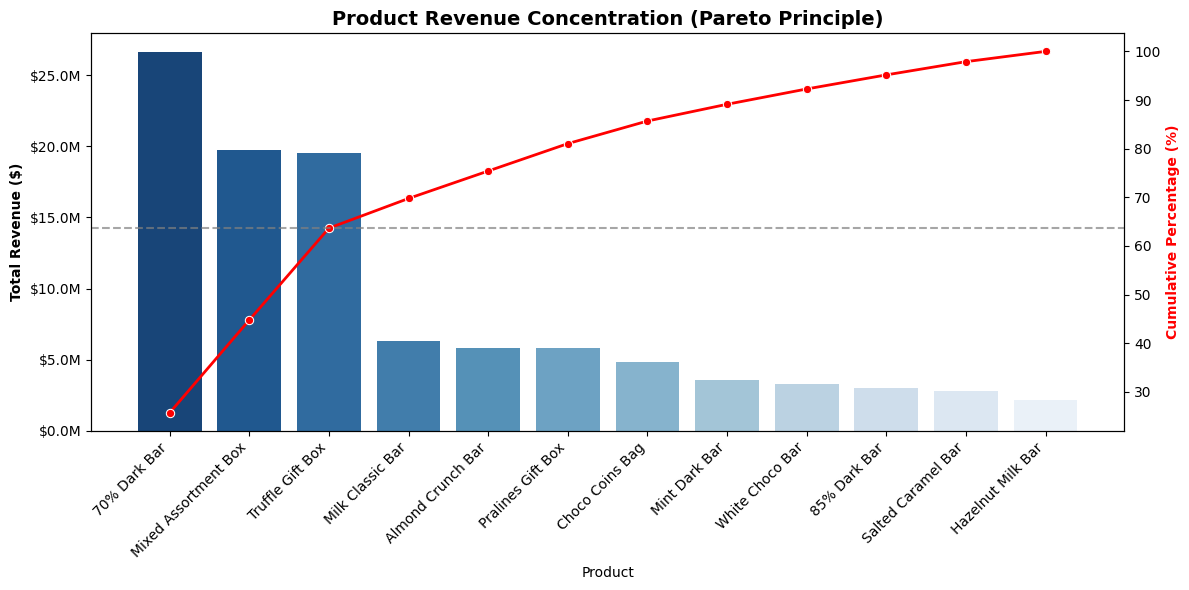

In [217]:
# Revenue by Product:
revenue_by_product = (
    df.groupby('Product')['Amount']
    .sum()
    .sort_values(ascending=False)
)
revenue_by_product_pct = (revenue_by_product / revenue_by_product.sum() * 100).round(1)

print("Revenue by Product")
print(revenue_by_product.round(0))
print(f"\nTop 3 products, % of total revenue: {revenue_by_product_pct.head(3).sum()}%")

# Visualization: Using the Pareto Chart
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    x=revenue_by_product.index, 
    y=revenue_by_product.values, 
    ax=ax1, 
    hue=revenue_by_product.index,
    palette='Blues_r',
    legend=False
)

ax1.set_ylabel('Total Revenue ($)', fontweight='bold')
ax1.set_xticks(range(len(revenue_by_product.index)))
ax1.set_xticklabels(revenue_by_product.index, rotation=45, ha='right')

ax1.set_title('Product Revenue Concentration (Pareto Principle)', fontweight='bold', fontsize=14)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x/1e6:.1f}M"))

# Secondary axis for cumulative percentage
ax2 = ax1.twinx()
cum_pct = (revenue_by_product.cumsum() / revenue_by_product.sum()) * 100
sns.lineplot(x=revenue_by_product.index, y=cum_pct.values, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', fontweight='bold', color='red')
ax2.axhline(revenue_by_product_pct.head(3).sum(), color='gray', linestyle='--', alpha=0.7) 

plt.tight_layout()

The top 3 products (70% Dark Bar, Mixed Assortment Box, Truffle Gift Box) account for exactly 63.7% of the $102.4M total revenue. This indicates heavy product concentration, meaning the financial success is highly dependent on our top 3 products.

**Revenue & Average Order Value by Channel**

Channel Summary


,total_revenue,avg_order_value,order_count
Channel,,,
Retail,54231201.99,466.71,116199
Wholesale,37785507.27,639.32,59103
Online,11391450.52,470.95,24188


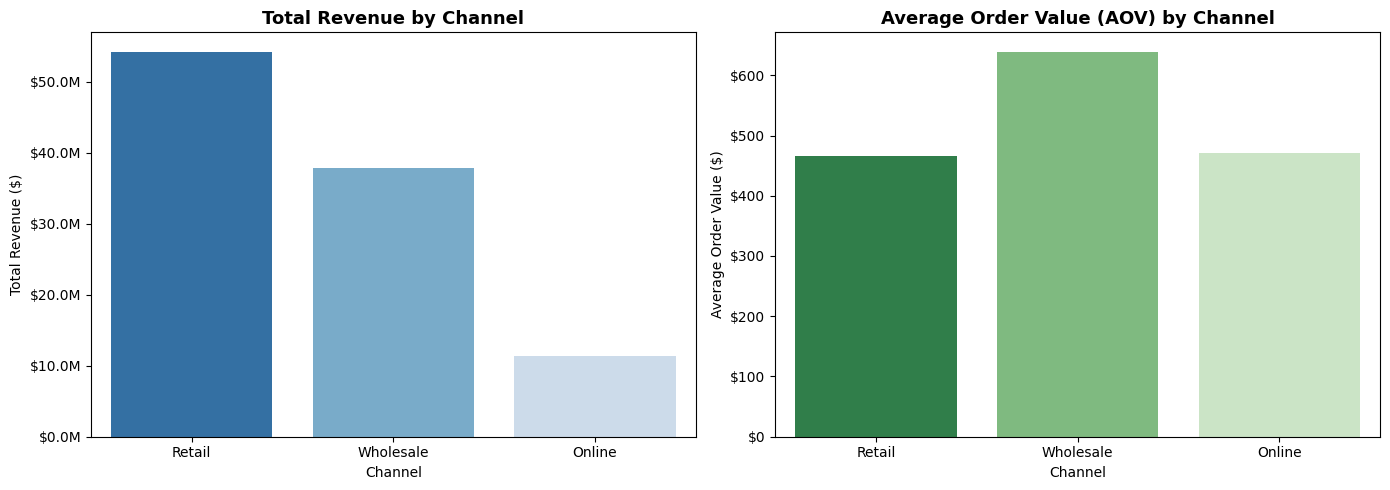

In [218]:
#  Revenue by Channel:
channel_summary = (
    df.groupby('Channel')
    .agg(
        total_revenue=('Amount', 'sum'),
        avg_order_value=('Amount', 'mean'),
        order_count=('Order_ID', 'count')
    )
    .sort_values('total_revenue', ascending=False)
)

print("Channel Summary")
display(channel_summary.round(2))

# Visualization: Dual Metrics (Total Revenue vs. Average Order Value)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Revenue using Bar Chart
sns.barplot(x=channel_summary.index, y='total_revenue', data=channel_summary, ax=axes[0], hue=channel_summary.index, palette='Blues_r', legend=False)
axes[0].set_title('Total Revenue by Channel', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Total Revenue ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x/1e6:.1f}M"))

# Average Order Value using Bar Chart
sns.barplot(x=channel_summary.index, y='avg_order_value', data=channel_summary, ax=axes[1], hue=channel_summary.index, palette='Greens_r', legend=False)
axes[1].set_title('Average Order Value (AOV) by Channel', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Average Order Value ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:.0f}"))

plt.tight_layout()
plt.show()

'Retail' Drives the highest total revenue at $53.7M and highest order volume of 115,070 orders.
'Wholesale' on the otherhand has a significantly higher Average Order Value of $639.23 compared to Retail at $466.75 and Online at $471.26.

**Revenue by Country (Geographic Concentration)**

Revenue by Country
Country
Australia    42805133.0
Brazil       36919027.0
Germany      11454093.0
India         6546989.0
Japan         5682918.0
Name: Amount, dtype: float64


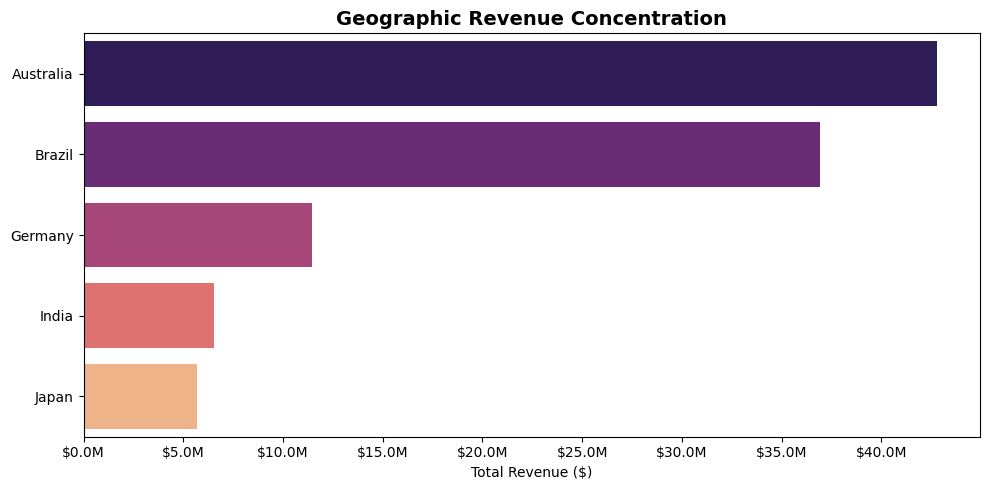

In [219]:
# Revenue by Country:
revenue_by_country = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

print("Revenue by Country")
print(revenue_by_country.round(0))

# Visualization: Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x=revenue_by_country.values, y=revenue_by_country.index, hue=revenue_by_country.index, palette='magma', legend=False,ax=ax
)
ax.set_title('Geographic Revenue Concentration', fontweight='bold', fontsize=14)
ax.set_xlabel('Total Revenue ($)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

Australia ($42.4M) and Brazil ($36.5M) completely dominate the geographic footprint, accounting for roughly 77% of all global revenue. Germany, India, and Japan lag significantly behind.

**Statistical Reality Checks**

Statistical Reality Checks
Discount vs Volume Correlation: 0.1777
Marketing Spend vs Revenue Correlation: 0.3529


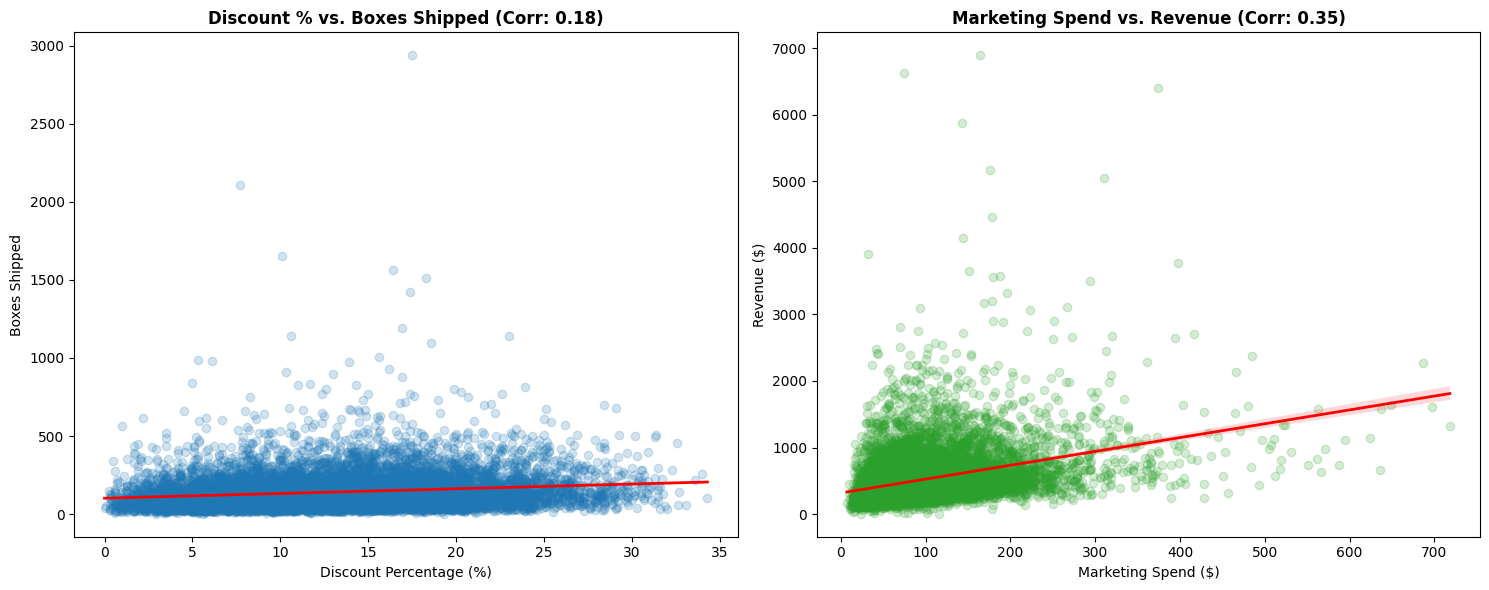

In [220]:
# Correlations:
corr_discount_boxes = df['Discount_Pct'].corr(df['Boxes_Shipped'])
corr_marketing_amount = df['Marketing_Spend'].corr(df['Amount'])

print("Statistical Reality Checks")
print(f"Discount vs Volume Correlation: {corr_discount_boxes:.4f}")
print(f"Marketing Spend vs Revenue Correlation: {corr_marketing_amount:.4f}")

# Visualizations: Regression Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sample the data to prevent overplotting visual noise
sample_df = df.sample(10000, random_state=42)

# Plot 1: Discount vs Boxes Shipped
sns.regplot(
    x='Discount_Pct', 
    y='Boxes_Shipped', 
    data=sample_df, 
    scatter_kws={'alpha':0.2, 'color':'#1f77b4'}, 
    line_kws={'color':'red', 'linewidth':2}, 
    ax=axes[0]
)
axes[0].set_title(f'Discount % vs. Boxes Shipped (Corr: {corr_discount_boxes:.2f})', fontweight='bold')
axes[0].set_xlabel('Discount Percentage (%)')
axes[0].set_ylabel('Boxes Shipped')

# Plot 2: Marketing Spend vs Amount
sns.regplot(
    x='Marketing_Spend', 
    y='Amount', 
    data=sample_df, 
    scatter_kws={'alpha':0.2, 'color':'#2ca02c'}, 
    line_kws={'color':'red', 'linewidth':2}, 
    ax=axes[1]
)
axes[1].set_title(f'Marketing Spend vs. Revenue (Corr: {corr_marketing_amount:.2f})', fontweight='bold')
axes[1].set_xlabel('Marketing Spend ($)')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

Discount_Pct vs. Boxes_Shipped: 0.1776 (Very weak). If higher discounts were successfully driving customers to buy in bulk, we would see a steep upward angle. Instead, the line is nearly flate

Marketing_Spend vs. Amount: 0.3528 (Moderate positive) indicating that marketing dollars do have some positive impact on overall order value, but it is not a perfectly guaranteed return.

 **4. BUSINESS RECOMMENDATIONS**

1. Reevaluate the Discounting Strategy: The data proves that aggressive discounting is not driving higher volume per order. The business is likely giving away pure profit margins unnecessarily. We recommend testing a reduction in the maximum discount caps, particularly on retail channels, and monitoring if volume remains steady as the data suggests it will.

2. Protect and Optimize the Core Portfolio: Our revenue is highly concentrated. Supply chain operations and marketing budgets must prioritize the top-performing products (like the 70% Dark Bar and Assortment Boxes) to ensure they never face stockouts.

3. Audit the Bottom Performers: Products at the far right of the Pareto chart (such as the Hazelnut Milk Bar and 85% Dark Bar) are dragging on production and inventory resources without delivering meaningful revenue. We recommend reviewing these for potential discontinuation or restricting them to specific high-performing regions.

4. Targeted Marketing Deep-Dive: While marketing spend shows a moderate positive relationship with revenue, it is more complex than that. With further analysis using Power BI , I will analyze marketing efficiency (Revenue per Marketing Dollar) segmented by Channel and Country to identify exactly where those dollars generate the highest return.

**Export Cleaned Dataset**

Time to export to Power BI for further exploratory analysis and Visualizations


In [221]:
output_filename = 'Chocolate_Sales_Cleaned_For_BI.csv'
df.to_csv(output_filename, index=False)

print(f"EDA Complete: Data successfully exported to {output_filename}")

EDA Complete: Data successfully exported to Chocolate_Sales_Cleaned_For_BI.csv
